# Box-Cox + Gaussian Mixture Modeling

Rebuild the synthetic transfer workflow focusing on distribution calibration and clustering without user-specific conditioning.


1. Load the original transfer records.
2. Apply Box-Cox power transforms to address skew.
3. Fit a Gaussian Mixture Model directly on the transformed features.


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from sklearn.mixture import GaussianMixture

In [7]:
data_path = Path('og-transfer.csv')
df_raw = pd.read_csv(data_path)
df_raw = df_raw.rename(columns={df_raw.columns[0]: 'record_id'})
df = df_raw.copy()
df.head()

,record_id,grp_uuid,user_id,request_time,grp_status,encrypt_data,grp_delete,st_files,st_dirs,st_successful,st_failed,st_expired,st_canceled,st_bytes_xfered,st_faults,st_skipped_errors,src_host_ep_id,dst_host_ep_id,complete_time
0,0,cfa4b772-89f6-11df-a740-123139143882,1,2010-07-07 18:38:18.356061,2,False,False,10,0,10,0,0,0,1048576000,0,0,3,2,2010-07-07 18:39:01.877251
1,1,ee145032-89f6-11df-b8d4-123139143882,1,2010-07-07 18:39:09.395804,2,False,False,100,0,100,0,0,0,10485760000,0,0,3,2,2010-07-07 18:52:02.141284
2,2,729c901e-89fa-11df-b391-123139143882,1,2010-07-07 19:04:20.249963,2,False,False,10000,0,10000,0,0,0,1048576000000,160,0,3,2,2010-07-07 20:29:01.849598
3,3,ed741d70-8aa4-11df-94cf-123139143882,1,2010-07-08 15:24:40.780741,2,False,False,10,0,10,0,0,0,1048576000,0,0,3,2,2010-07-08 15:26:01.821227
4,4,a077cd2a-8ab1-11df-bd28-123139143882,1,2010-07-08 16:55:35.077651,2,False,False,10,0,10,0,0,0,1048576000,0,0,3,2,2010-07-08 16:56:01.686220


Select the transfer status indicators and throughput features for transformation. Box-Cox requires strictly positive inputs, so shift the frame by 1 before fitting the transformer.


In [8]:
feature_cols = [
    'st_dirs',
    'st_successful',
    'st_failed',
    'st_expired',
    'st_canceled',
    'st_bytes_xfered',
    'st_faults',
    'st_skipped_errors',
]
X = df[feature_cols].copy()
boxcox_shift = 1.0
X_boxcox_input = X + boxcox_shift

constant_cols = X_boxcox_input.columns[X_boxcox_input.nunique() <= 1].tolist()
if constant_cols:
    print(f'Skipping constant columns for Box-Cox: {constant_cols}')

constant_values = {col: X[col].iloc[0] for col in constant_cols}
boxcox_cols = [col for col in feature_cols if col not in constant_cols]

if boxcox_cols:
    transformer = PowerTransformer(method='box-cox', standardize=True)
    X_boxcox = transformer.fit_transform(X_boxcox_input[boxcox_cols])
    X_boxcox = pd.DataFrame(X_boxcox, columns=boxcox_cols, index=df.index)
    boxcox_lambdas = dict(zip(boxcox_cols, transformer.lambdas_))
else:
    transformer = None
    X_boxcox = pd.DataFrame(index=df.index)
    boxcox_lambdas = {}

gmm_features = X_boxcox.columns.tolist()
X_boxcox.head()


Skipping constant columns for Box-Cox: ['st_skipped_errors']


,st_dirs,st_successful,st_failed,st_expired,st_canceled,st_bytes_xfered,st_faults
0,-0.426653,1.231584,-0.077693,-0.369242,-0.535659,1.053080,-0.839775
1,-0.426653,1.903610,-0.077693,-0.369242,-0.535659,1.236673,-0.839775
2,-0.426653,2.192281,-0.077693,-0.369242,-0.535659,1.575785,1.111623
3,-0.426653,1.231584,-0.077693,-0.369242,-0.535659,1.053080,-0.839775
4,-0.426653,1.231584,-0.077693,-0.369242,-0.535659,1.053080,-0.839775


In [9]:
if X_boxcox.empty:
    raise ValueError('No features left after Box-Cox preprocessing; check constant columns.')

component_grid = range(1, 15)
bic_records = []
for n in component_grid:
    gmm = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42,
        reg_covar=1e-6
    )
    gmm.fit(X_boxcox)
    bic_records.append({'n_components': n, 'bic': gmm.bic(X_boxcox)})
bic_df = pd.DataFrame(bic_records)
bic_df


,n_components,bic
0,1,9301.935431
1,2,1171.919502
2,3,-4943.121094
3,4,-9727.660192
4,5,-14895.951805
5,6,-14393.699825
6,7,-17403.596148
7,8,-17543.569493
8,9,-19846.633587
9,10,-20282.250075


In [10]:
best_row = bic_df.sort_values('bic').iloc[0]
best_n = int(best_row['n_components'])
best_gmm = GaussianMixture(
  n_components=best_n,
  covariance_type='full',random_state=42,
  reg_covar=1e-6
)
best_gmm.fit(X_boxcox)
cluster_assignments = best_gmm.predict(X_boxcox)
df_clusters = df.assign(cluster=cluster_assignments)
cluster_sizes = df_clusters['cluster'].value_counts().sort_index()
best_n, cluster_sizes


(14,
 cluster
 0      52
 1       6
 2      62
 3       3
 4      22
 5      21
 6     138
 7      47
 8      24
 9      53
 10     26
 11      8
 12     26
 13     12
 Name: count, dtype: int64)

In [11]:
cluster_summary = pd.DataFrame(best_gmm.means_, columns=X_boxcox.columns)
cluster_summary['weight'] = best_gmm.weights_
cluster_summary


,st_dirs,st_successful,st_failed,st_expired,st_canceled,st_bytes_xfered,st_faults,weight
0,-0.426653,-1.153316,-0.077693,2.700391,-0.535659,-1.130163,1.084077,0.104000
1,-0.426653,-0.146180,-0.077693,-0.369242,-0.535659,0.921250,-0.399762,0.012000
2,-0.426653,-1.153316,-0.077693,-0.369242,1.437742,-1.130163,0.159533,0.124000
3,2.343697,-1.153316,12.871156,-0.369242,-0.535659,-1.130163,-0.399762,0.006000
4,-0.174803,1.826895,-0.077693,-0.369242,2.483766,1.430357,1.109361,0.044000
5,2.344159,1.715064,-0.077693,-0.369242,-0.535659,0.796164,-0.621857,0.042000
6,-0.426653,-0.146180,-0.077693,-0.369242,-0.535659,-0.114131,-0.839775,0.275999
7,-0.426653,-0.146180,-0.077693,-0.369242,-0.535659,0.565377,1.503095,0.094000
8,2.343697,-0.775640,-0.077693,-0.369242,1.501373,-1.130163,0.053631,0.048000
9,-0.426653,0.997587,-0.077693,-0.369242,-0.535659,1.093922,-0.839775,0.106000


In [12]:
def quantile_calibrate(source_values, target_values, quantile_levels=None):
    source = np.asarray(source_values, dtype=float)
    target = np.asarray(target_values, dtype=float)
    if source.size == 0:
        return source
    else:
        quantile_levels = np.asarray(quantile_levels, dtype=float)
    quantile_levels = np.unique(np.clip(quantile_levels, 0.0, 1.0))
    quantile_levels.sort()
    source_q = np.maximum.accumulate(np.quantile(source, quantile_levels))
    target_q = np.maximum.accumulate(np.quantile(target, quantile_levels))
    eps = 1e-6
    for i in range(1, len(source_q)):
        if source_q[i] <= source_q[i - 1]:
            source_q[i] = source_q[i - 1] + eps
        if target_q[i] <= target_q[i - 1]:
            target_q[i] = target_q[i - 1] + eps
    calibrated = np.interp(source, source_q, target_q, left=target_q[0], right=target_q[-1])
    tail_ratio = (target_q[-1] + eps) / (source_q[-1] + eps)
    higher_mask = source > source_q[-1]
    if higher_mask.any():
        calibrated[higher_mask] = target_q[-1] + (source[higher_mask] - source_q[-1]) * tail_ratio
    lower_mask = source < source_q[0]
    if lower_mask.any():
        if len(source_q) > 1:
            slope = (target_q[1] - target_q[0]) / max(source_q[1] - source_q[0], eps)
        else:
            slope = tail_ratio
        calibrated[lower_mask] = target_q[0] + (source[lower_mask] - source_q[0]) * slope
    return calibrated


In [13]:
n_samples = len(df)
synthetic_latent, synthetic_labels = best_gmm.sample(n_samples)
synthetic_latent = pd.DataFrame(synthetic_latent, columns=gmm_features, index=df.index)

synthetic_positive = transformer.inverse_transform(synthetic_latent.values)
synthetic_positive = pd.DataFrame(synthetic_positive, columns=gmm_features, index=df.index)
synthetic_features = synthetic_positive - boxcox_shift
synthetic_features = synthetic_features.replace([np.inf, -np.inf], np.nan)
synthetic_features = synthetic_features.fillna(0)
synthetic_features = synthetic_features.clip(lower=0)

quantile_levels = np.array([0.0, 0.5, 0.9, 0.95, 0.99, 0.995])
bytes_col = 'st_bytes_xfered'
if bytes_col in synthetic_features.columns and bytes_col in df.columns:
    target_values = df[bytes_col].astype(float).values
    source_values = synthetic_features[bytes_col].astype(float).values
    calibrated = quantile_calibrate(
        source_values,
        target_values,
        quantile_levels=quantile_levels,
    )
    synthetic_features[bytes_col] = np.clip(calibrated, 0, None)

count_like_cols = [
    'st_dirs',
    'st_successful',
    'st_failed',
    'st_expired',
    'st_canceled',
    'st_bytes_xfered',
    'st_faults',
]
count_like_cols = [col for col in count_like_cols if col in synthetic_features.columns]
rounded_counts = synthetic_features[count_like_cols].round().clip(lower=0)
synthetic_features[count_like_cols] = rounded_counts.astype(int)

status_cols = [col for col in ['st_successful', 'st_failed', 'st_expired', 'st_canceled'] if col in synthetic_features.columns]
totals = None
if status_cols:
    totals = synthetic_features[status_cols].sum(axis=1)
if 'st_dirs' in synthetic_features.columns:
    dirs_series = synthetic_features['st_dirs']
    totals = dirs_series if totals is None else totals + dirs_series
if totals is None:
    totals = pd.Series(0, index=synthetic_features.index)
synthetic_features['st_files'] = totals.clip(lower=0).round().astype(int)

if {'st_dirs', 'st_files'}.issubset(synthetic_features.columns):
    dirs = synthetic_features['st_dirs'].astype(int)
    files = synthetic_features['st_files'].astype(int)
    synthetic_features['st_dirs'] = np.minimum(dirs, files)
    synthetic_features['st_dirs'] = synthetic_features['st_dirs'].astype(int)

for col in constant_cols:
    synthetic_features[col] = constant_values[col]

synthetic_features['cluster'] = synthetic_labels

synthetic_dataset = df.copy()
for col in synthetic_features.columns:
    if col in synthetic_dataset.columns:
        synthetic_dataset[col] = synthetic_features[col]
synthetic_dataset = synthetic_dataset[df.columns]
assert list(synthetic_dataset.columns) == list(df.columns)
synthetic_dataset.head()
synthetic_dataset.to_csv("output/output.csv", index=False)


/Users/kafka/Desktop/research/gmm-synth-transfer/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


### (source_q[i], target_q[i]) plot

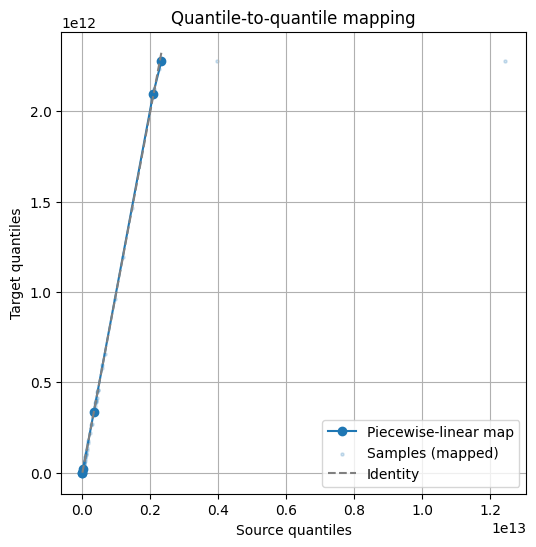

In [14]:
target_values = df[bytes_col].astype(float).values
source_values = synthetic_features[bytes_col].astype(float).values
source = np.asarray(source_values, dtype=float)
target = np.asarray(target_values, dtype=float)

quantile_levels = np.asarray(quantile_levels, dtype=float)
quantile_levels = np.unique(np.clip(quantile_levels, 0.0, 1.0))
quantile_levels.sort()
source_q = np.maximum.accumulate(np.quantile(source, quantile_levels))
target_q = np.maximum.accumulate(np.quantile(target, quantile_levels))
plt.figure(figsize=(6, 6))
plt.plot(source_q, target_q, marker='o', label='Piecewise-linear map')
plt.scatter(source, np.interp(source, source_q, target_q), s=5, alpha=0.2, label='Samples (mapped)')
plt.plot([source_q.min(), source_q.max()],
         [source_q.min(), source_q.max()],
         '--', color='gray', label='Identity')
plt.xlabel('Source quantiles')
plt.ylabel('Target quantiles')
plt.title('Quantile-to-quantile mapping')
plt.legend()
plt.grid(True)
plt.show()